# Imports

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential, regularizers
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    RandomFlip, RandomRotation, BatchNormalization
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import AdamW, Adam
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, UpSampling2D
from tensorflow.keras.models import Model


# Cargar Cifar100

Cargar el dataset

In [ ]:
# *** Mejorar la semilla aleatoria para reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Cargar el conjunto de datos CIFAR-100
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data()


Eliminar el 80% de las etiquetas de entrenamiento

In [ ]:
# *** Configuración mejorada de división de datos
frac_to_remove = 0.8
num_train = x_train.shape[0]
num_unlabeled = int(num_train * frac_to_remove)
num_labeled = num_train - num_unlabeled

indices = np.arange(num_train)
np.random.shuffle(indices)

labeled_indices = indices[:num_labeled]
unlabeled_indices = indices[num_labeled:]

x_train_labeled = x_train[labeled_indices]
y_train_labeled = y_train[labeled_indices]

x_train_unlabeled = x_train[unlabeled_indices]
y_train_unlabeled = np.full_like(y_train[unlabeled_indices], -1)

y_test_labeled = y_test

# *** Dividir conjunto de validación del etiquetado
x_train_labeled, x_val, y_train_labeled, y_val = train_test_split(
    x_train_labeled, y_train_labeled,
    test_size=0.2, random_state=SEED
)


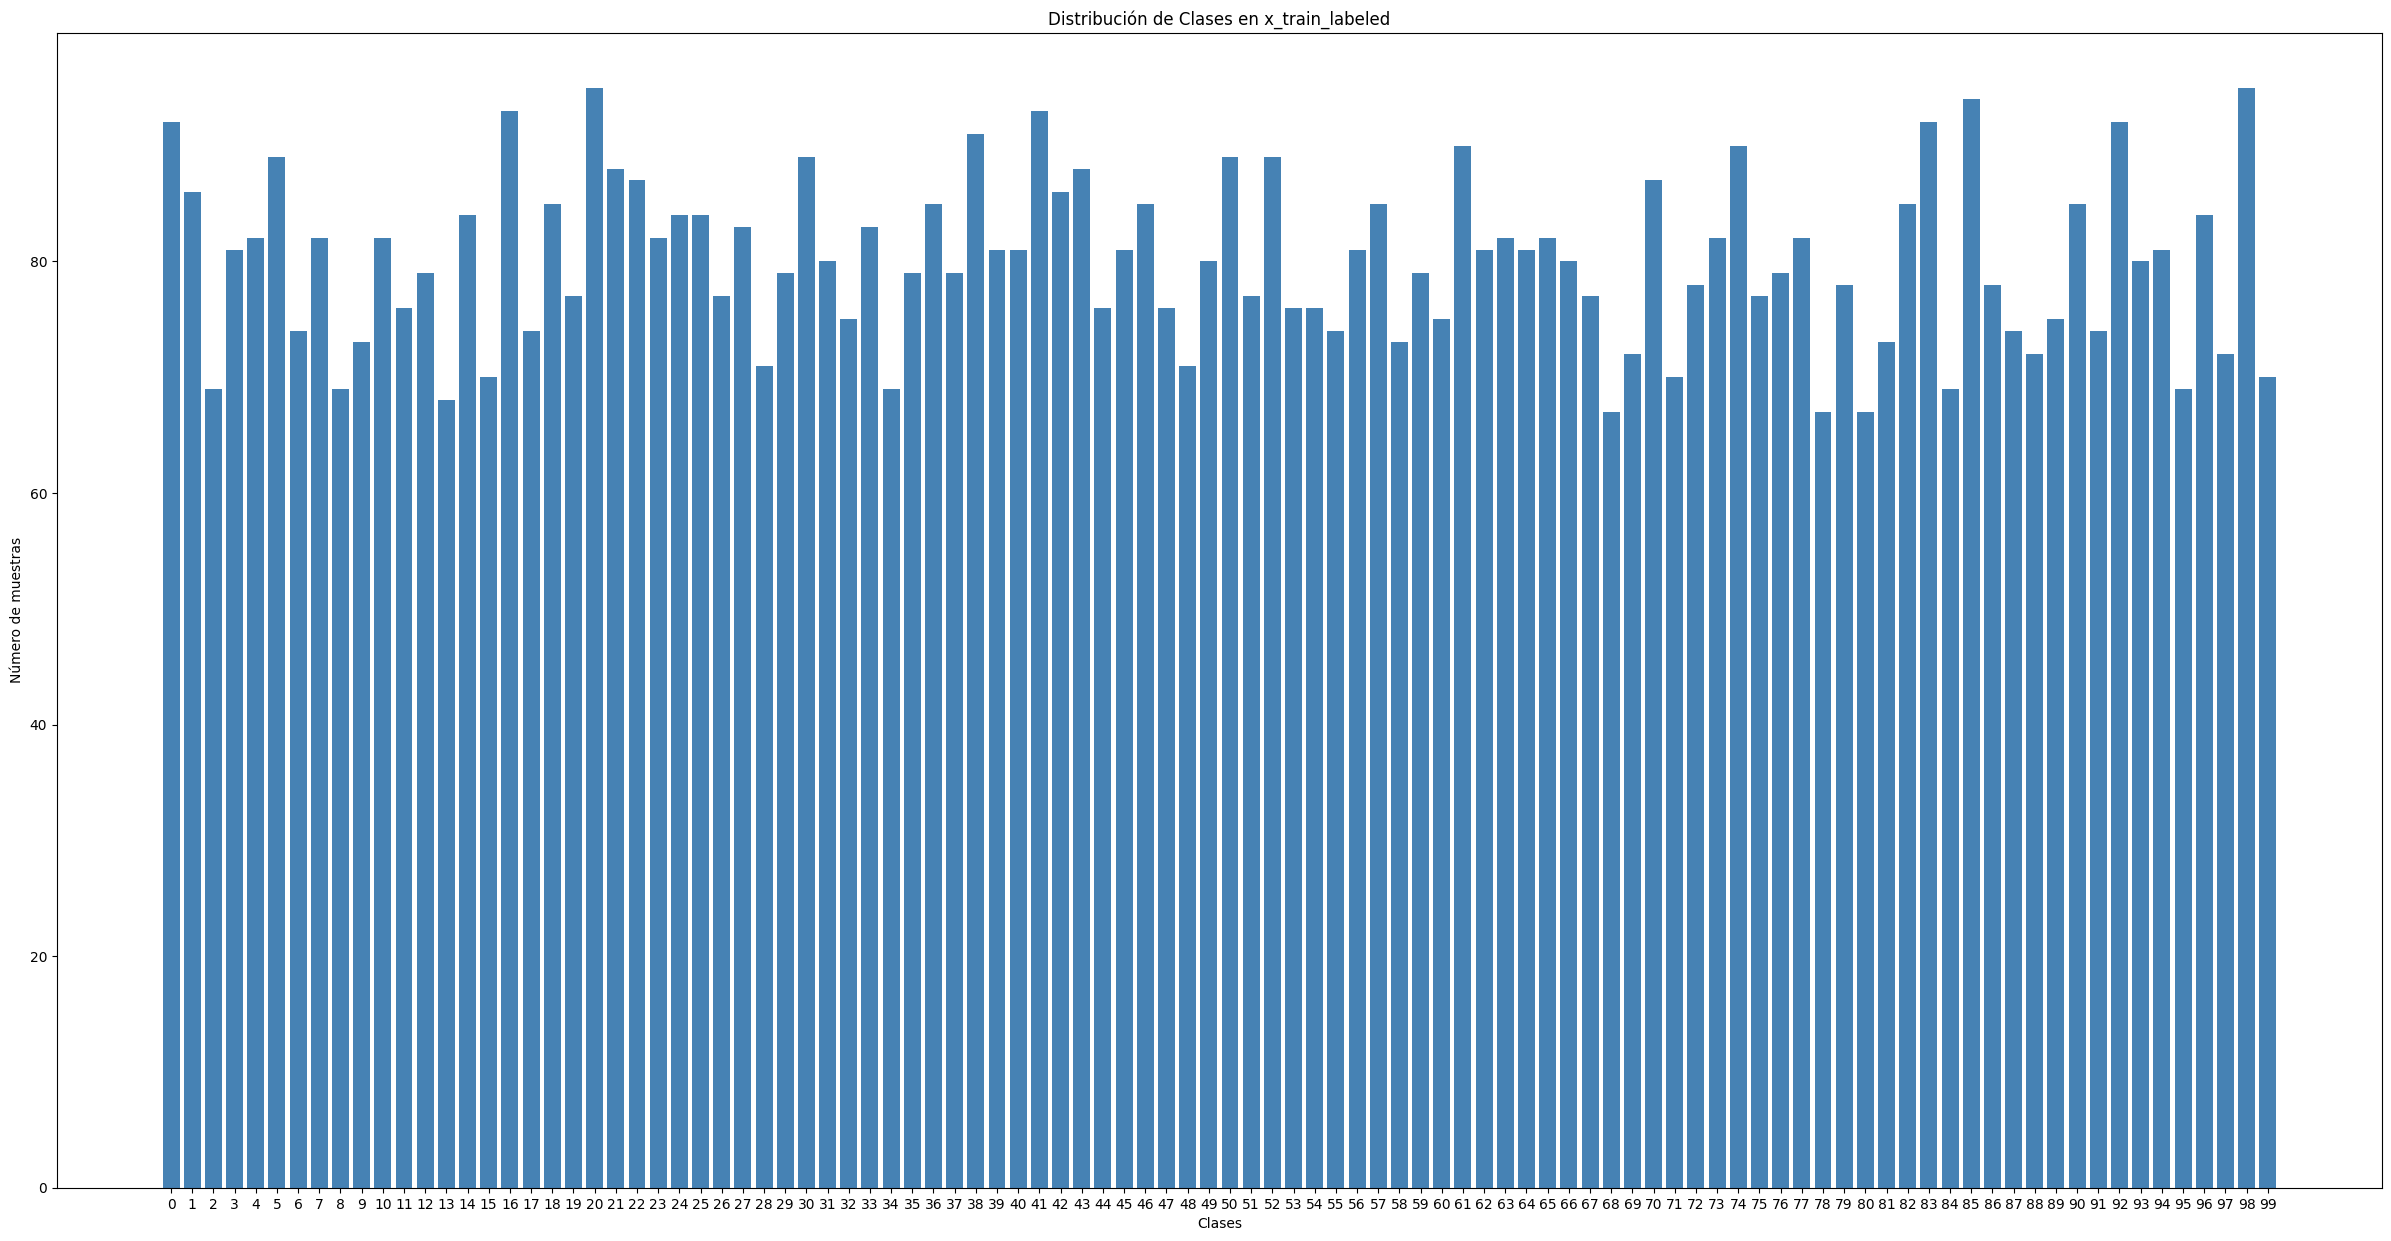

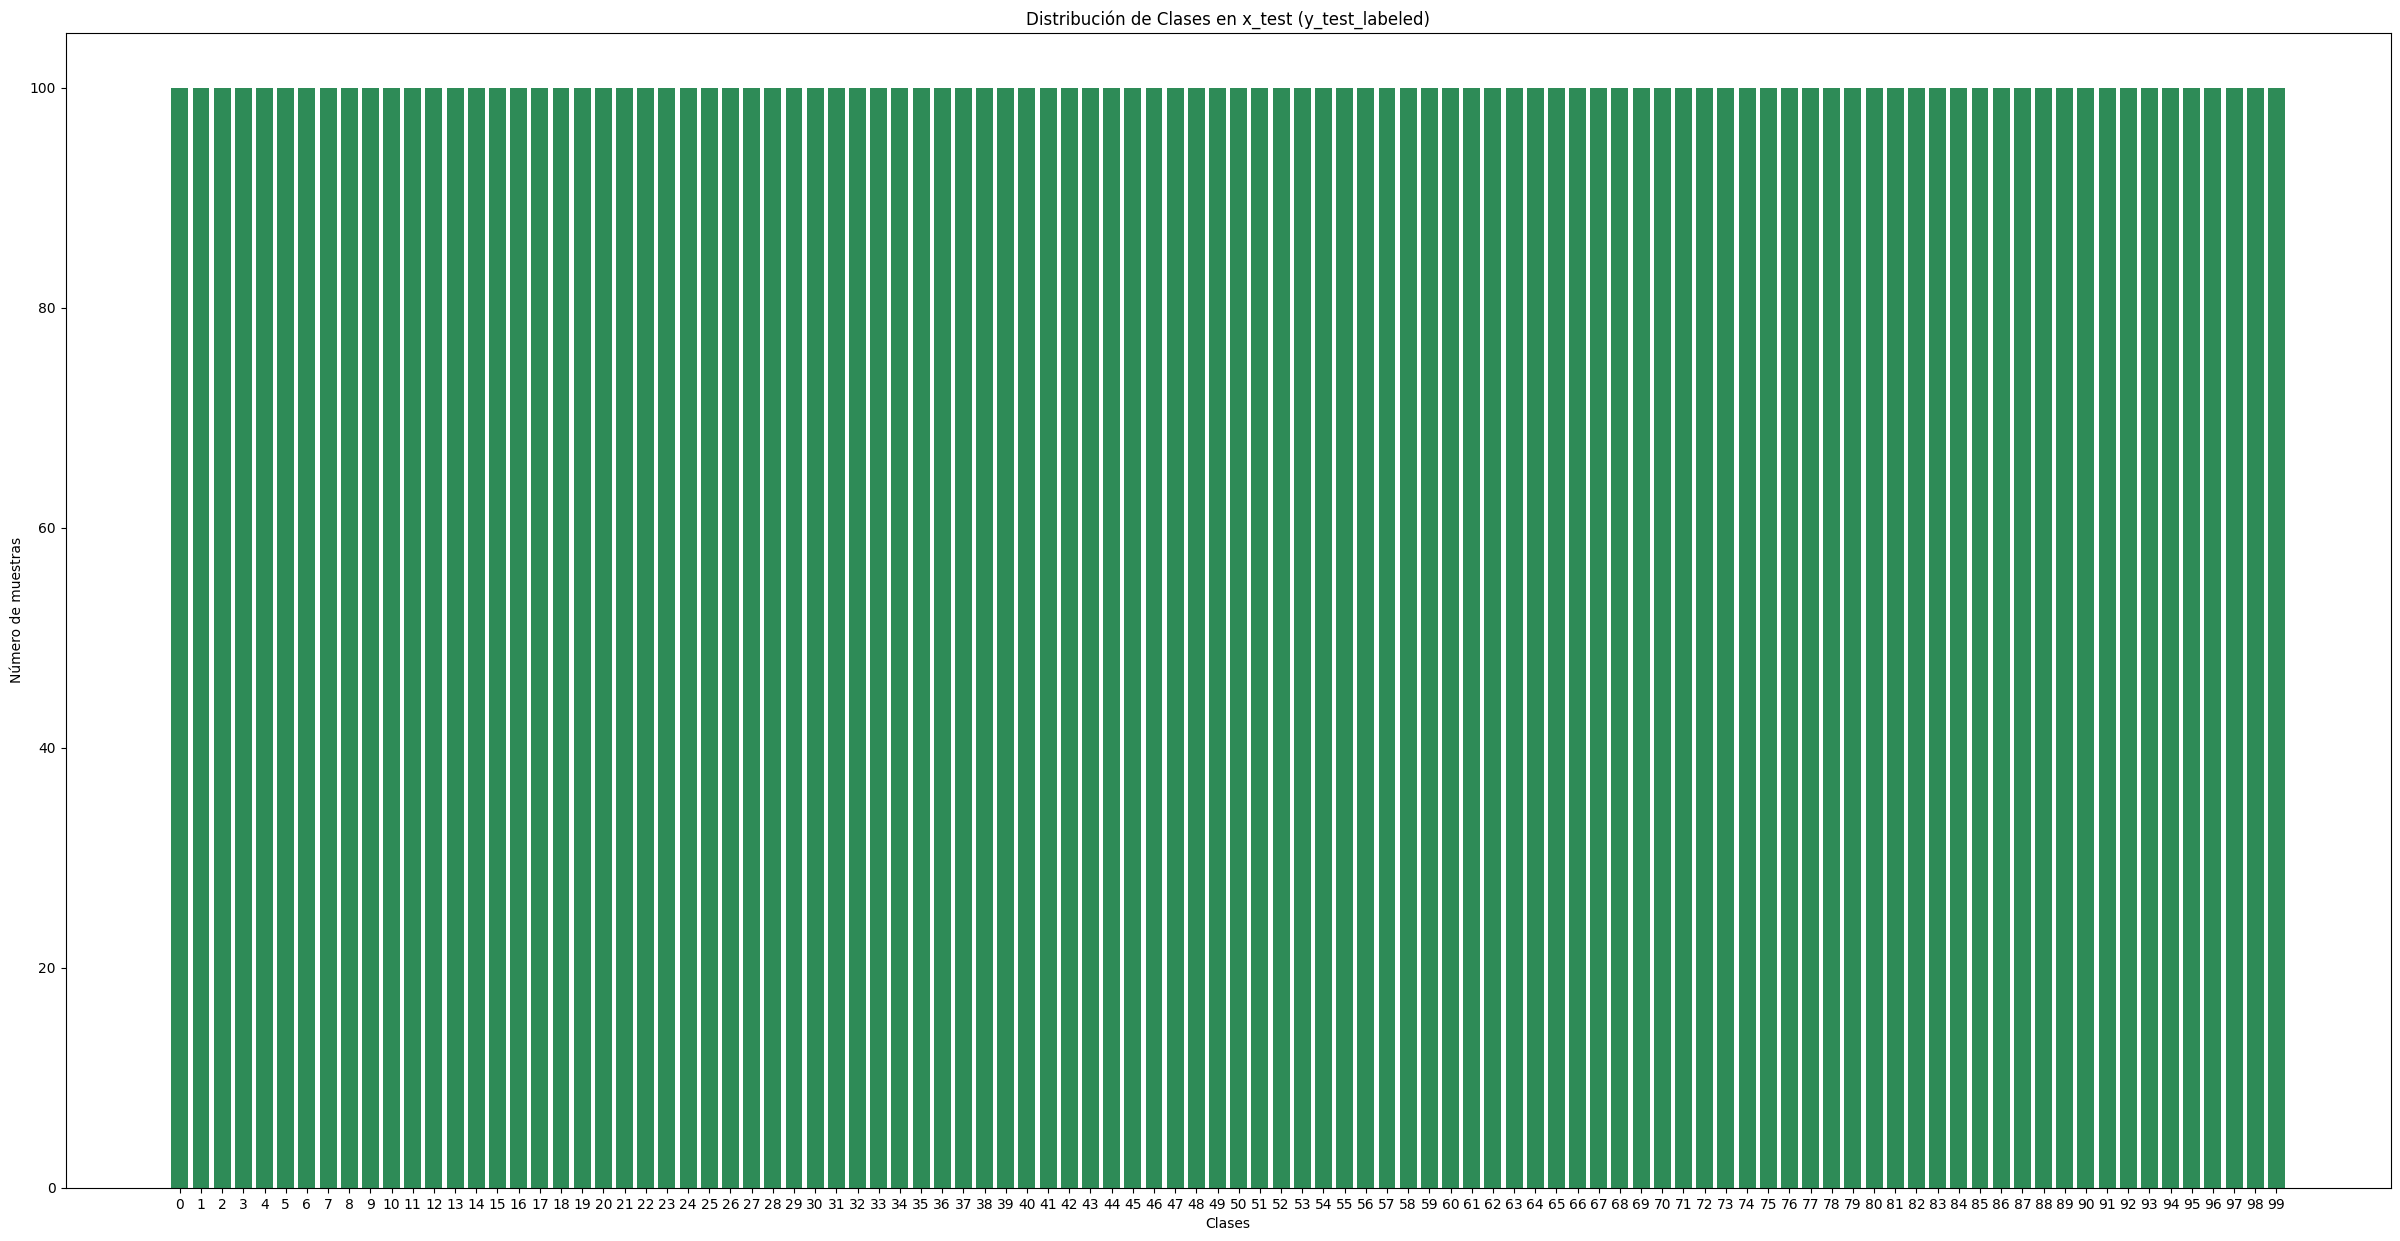

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Distribución de clases en el conjunto de entrenamiento etiquetado
clases_train, conteos_train = np.unique(y_train_labeled, return_counts=True)
plt.figure(figsize=(30, 15))
plt.bar(clases_train, conteos_train, color='steelblue')
plt.title('Distribución de Clases en x_train_labeled')
plt.xlabel('Clases')
plt.ylabel('Número de muestras')
plt.xticks(clases_train)  # Asegura que se muestren todas las clases
plt.show()

# Distribución de clases en el conjunto de test
clases_test, conteos_test = np.unique(y_test_labeled, return_counts=True)
plt.figure(figsize=(30, 15))
plt.bar(clases_test, conteos_test, color='seagreen')
plt.title('Distribución de Clases en x_test (y_test_labeled)')
plt.xlabel('Clases')
plt.ylabel('Número de muestras')
plt.xticks(clases_test)  # Asegura que se muestren todas las clases
plt.show()


In [ ]:
# *** Normalización mejorada con datos de validación
def normalize(x):
    return x.astype('float32') / 255.0

x_train_labeled = normalize(x_train_labeled)
x_val = normalize(x_val)
x_test_labeled = normalize(x_test)
x_train_unlabeled = normalize(x_train_unlabeled)

y_train_labeled = to_categorical(y_train_labeled.squeeze(), 100)
y_val = to_categorical(y_val.squeeze(), 100)
y_test_labeled = to_categorical(y_test_labeled.squeeze(), 100)

In [ ]:
print(len(y_train_labeled[0]))

100


# Ejercicio 1

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


class MiClasificador:
    def __init__(self):
        self.model = Sequential([

            Conv2D(64, (3,3), activation='relu', padding='same',
                   kernel_regularizer=regularizers.l2(1e-4)),
            BatchNormalization(),
            Conv2D(64, (3,3), activation='relu', padding='same'),
            MaxPooling2D((2,2)),
            Dropout(0.2),

            Conv2D(128, (3,3), activation='relu', padding='same'),
            BatchNormalization(),
            Conv2D(128, (3,3), activation='relu', padding='same'),
            MaxPooling2D((2,2)),
            Dropout(0.2),

            Conv2D(256, (3,3), activation='relu', padding='same'),
            BatchNormalization(),
            Conv2D(256, (3,3), activation='relu', padding='same'),
            MaxPooling2D((2,2)),
            Dropout(0.2),

            Flatten(),
            Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
            BatchNormalization(),
            Dropout(0.2),
            Dense(100, activation='softmax')
        ])

        self.optimizer = AdamW(learning_rate=3e-4, weight_decay=1e-4)
        self.model.compile(
            loss='categorical_crossentropy',
            optimizer=self.optimizer,
            metrics=['accuracy']
        )


    def fit(self, X, y, epochs, batch_size=64, validation_data=None, verbose=1, callbacks=None, sample_weight=None, **kwargs):

        history = self.model.fit(
            X, y,
            batch_size=batch_size,
            epochs=epochs,
            validation_data=validation_data,
            verbose=verbose,
            sample_weight=sample_weight,
            **kwargs
        )
        return history


    # *** Mantener los demás métodos igual
    def predict(self, X):
        return np.argmax(self.model.predict(X, verbose=0), axis=1)

    def predict_proba(self, X):
        return self.model.predict(X, verbose=0)

    def score(self, X, y):
      loss, accuracy = self.model.evaluate(X, y, verbose=0)
      return {"loss": loss, "accuracy": accuracy}

    def summary(self):
        self.model.summary()

    def __del__(self):
        del self.model
        tf.keras.backend.clear_session()


In [ ]:
modelo_1 = MiClasificador()


# Entrenar el modelo
history1 = modelo_1.fit(x_train_labeled, y_train_labeled, epochs=30, batch_size=64, validation_data=(x_test_labeled, y_test_labeled), sample_weight = np.ones(len(y_train_labeled)))

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.0404 - loss: 4.9319 - val_accuracy: 0.0109 - val_loss: 5.1507
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.1180 - loss: 3.9454 - val_accuracy: 0.0153 - val_loss: 5.2876
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.1743 - loss: 3.5886 - val_accuracy: 0.0167 - val_loss: 5.2535
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.2286 - loss: 3.2977 - val_accuracy: 0.0930 - val_loss: 4.0906
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.2818 - loss: 3.0131 - val_accuracy: 0.1882 - val_loss: 3.5628
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.3409 - loss: 2.7383 - val_accuracy: 0.1522 - val_loss: 3.8777
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.3975 - loss: 2.4950 - val_accuracy: 0.2476 - val_loss: 3.2968
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4469 - loss: 2.2728 - val_ac

In [ ]:
modelo_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (64, 32, 32, 64)            │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (64, 32, 32, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (64, 32, 32, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (64, 16, 16, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (64, 16, 16, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (64, 16, 16, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (64, 16, 16, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (64, 16, 16, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (64, 8, 8, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (64, 8, 8, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (64, 8, 8, 256)             │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (64, 8, 8, 256)             │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (64, 8, 8, 256)             │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (64, 4, 4, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (64, 4, 4, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (64, 4096)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (64, 512)                   │       2,097,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (64, 512)                   │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (64, 512)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 9,890,798 (37.73 MB)

 Trainable params: 3,296,292 (12.57 MB)

 Non-trainable params: 1,920 (7.50 KB)

 Optimizer params: 6,592,586 (25.15 MB)

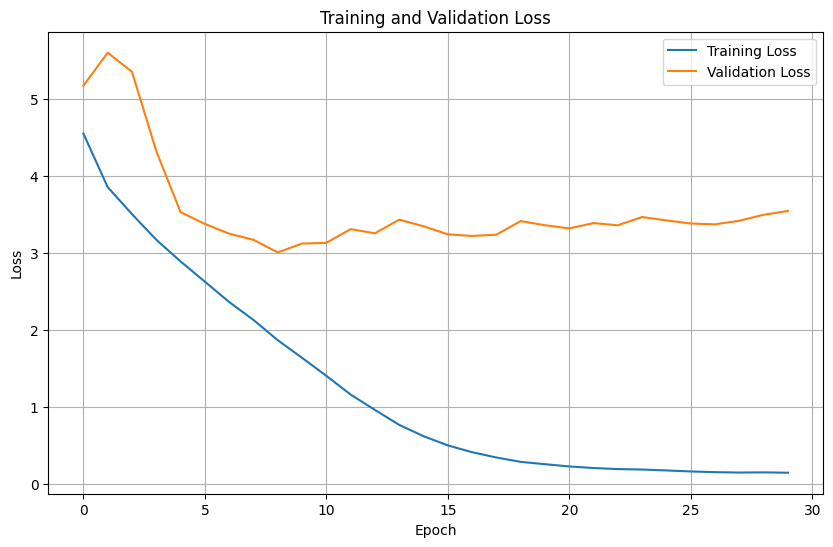

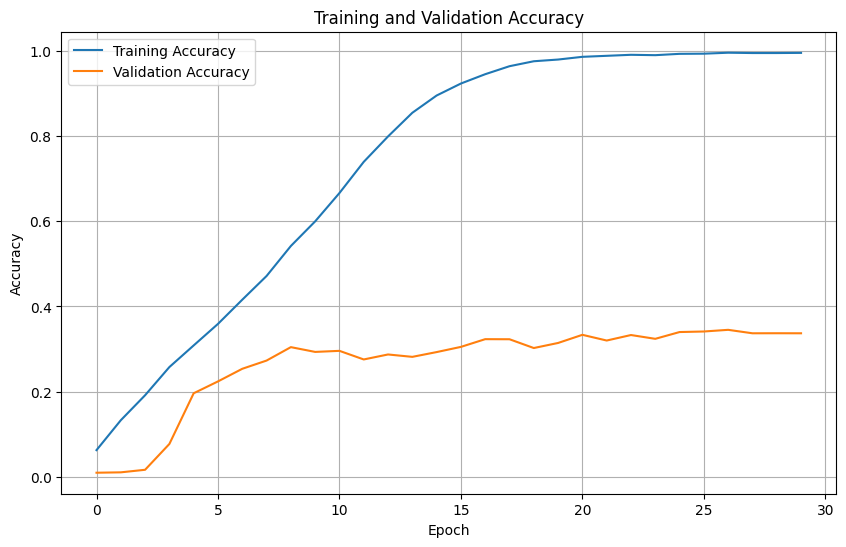

In [ ]:
train_loss = history1.history['loss']
val_loss = history1.history['val_loss']
train_acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']

# Gráfica para Loss
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Gráfica para Accuracy
plt.figure(figsize=(10, 6))
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluar el modelo en el conjunto de prueba
modelo_1.score(x_test_labeled, y_test_labeled)

{'loss': 3.5951714515686035, 'accuracy': 0.3336000144481659}

# Ejercicio 2

## Modelo

In [ ]:
# *** Arquitectura mejorada con egularización
class MiClasificador:
    def __init__(self):
        self.model = Sequential([

            Conv2D(64, (3,3), activation='relu', padding='same',
                   kernel_regularizer=regularizers.l2(1e-4)),
            BatchNormalization(),
            Conv2D(64, (3,3), activation='relu', padding='same'),
            MaxPooling2D((2,2)),
            Dropout(0.2),

            Conv2D(128, (3,3), activation='relu', padding='same'),
            BatchNormalization(),
            Conv2D(128, (3,3), activation='relu', padding='same'),
            MaxPooling2D((2,2)),
            Dropout(0.2),

            Conv2D(256, (3,3), activation='relu', padding='same'),
            BatchNormalization(),
            Conv2D(256, (3,3), activation='relu', padding='same'),
            MaxPooling2D((2,2)),
            Dropout(0.2),

            Flatten(),
            Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
            BatchNormalization(),
            Dropout(0.2),
            Dense(100, activation='softmax')
        ])

        self.optimizer = AdamW(learning_rate=3e-4, weight_decay=1e-4)
        self.model.compile(
            loss='categorical_crossentropy',
            optimizer=self.optimizer,
            metrics=['accuracy']
        )

    def fit(self, X, y, epochs_base = 20, sample_weight=None):

        # *** Entrenamiento con conjunto de validación
        return self.model.fit(
            X, y,
            batch_size=64,
            epochs=epochs_base,
            sample_weight=sample_weight,
            validation_data=(x_val, y_val),
            verbose=0
        )

    # *** Mantener los demás métodos igual
    def predict(self, X):
        return np.argmax(self.model.predict(X, verbose=0), axis=1)

    def predict_proba(self, X):
        return self.model.predict(X, verbose=0)

    def score(self, X, y):
        return self.model.evaluate(X, y, verbose=0)[1]

    def __del__(self):
        del self.model
        tf.keras.backend.clear_session()


## Funcion train auto-aprendizaje

In [ ]:
import matplotlib.pyplot as plt

def self_training_v2(model_func, x_train, y_train, unlabeled_data, x_test, y_test, epochs_base=20,
                     thresh=0.95, num_modelos=5):

    train_data = x_train.copy()
    train_label = y_train.copy()
    current_unlabeled = unlabeled_data.copy()

    sample_weights = np.ones(len(train_label))
    overall_test_scores = []  # Precisión en test al final de cada modelo
    overall_train_scores = []  # Precisión en train al final de cada modelo
    best_score = 0
    best_model = None

    print(f"Inicio: {len(train_data)} ejemplos etiquetados, {len(current_unlabeled)} sin etiquetar")

    for train_epoch in range(num_modelos):
        model = model_func()

        # Entrenar el modelo durante 'epochs_base' épocas y almacenar el historial
        history = model.fit(train_data, train_label, epochs_base=epochs_base, sample_weight=sample_weights)

        # Extraer las métricas de entrenamiento y validación para cada epoch_base
        train_history = history.history['accuracy']
        test_history = history.history['val_accuracy']

        # Graficar la evolución de accuracy durante las epochs_base de este modelo
        plt.figure()
        plt.plot(range(1, epochs_base+1), train_history, marker='o', label='Train Accuracy')
        plt.plot(range(1, epochs_base+1), test_history, marker='o', label='Test Accuracy')
        plt.xlabel('Época Base')
        plt.ylabel('Accuracy')
        plt.title(f'Evolución de Accuracy en el Modelo {train_epoch+1}')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Calcular la precisión final del modelo entrenado
        final_train_acc = model.score(train_data, train_label)
        final_test_acc = model.score(x_test, y_test)

        overall_train_scores.append(final_train_acc)
        overall_test_scores.append(final_test_acc)

        if final_test_acc > best_score:
            best_score = final_test_acc
            best_model = model

        # Generar pseudo-etiquetas
        y_proba = model.predict_proba(current_unlabeled)
        y_conf = np.max(y_proba, axis=1)
        y_pred = np.argmax(y_proba, axis=1)

        # Selección conservadora de pseudo-etiquetas
        high_conf = y_conf > thresh
        x_new = current_unlabeled[high_conf]
        y_new = to_categorical(y_pred[high_conf], num_classes=100)
        confidences = y_conf[high_conf]

        if len(x_new) > 0:
            # Se añaden los nuevos ejemplos (x_new) al conjunto de entrenamiento existente
            train_data = np.concatenate([train_data, x_new], axis=0)
            # Se añaden las pseudo-etiquetas correspondientes (y_new) al conjunto de etiquetas existente
            train_label = np.concatenate([train_label, y_new], axis=0)

            # Se actualizan los pesos de entrenamiento:
            # Los nuevos pesos se establecen igual a la confianza del modelo en cada ejemplo,
            new_weights = np.concatenate([sample_weights, confidences])
            sample_weights = new_weights

            # Se eliminan de los datos sin etiquetar los ejemplos que ya se han añadido al entrenamiento
            current_unlabeled = current_unlabeled[~high_conf]


            # Balancear clases (muestreo estratificado aproximado)
            unique, counts = np.unique(y_pred[high_conf], return_counts=True)
            class_distribution = dict(zip(unique, counts))
            print(f"Distribución de clases añadidas en el modelo {train_epoch+1}: {class_distribution}")

        print(f"Modelo {train_epoch+1}: Train Acc final={final_train_acc:.4f}, Test Acc final={final_test_acc:.4f}, "
              f"Etiquetados={len(train_data)}, Sin etiquetar={len(current_unlabeled)}")

        if len(current_unlabeled) == 0:
            print("¡Todos los datos etiquetados!")
            break

    # Devolver el mejor modelo encontrado junto con las métricas generales
    return best_model, overall_test_scores, overall_train_scores


## Entrenar

Inicio: 8000 ejemplos etiquetados, 40000 sin etiquetar


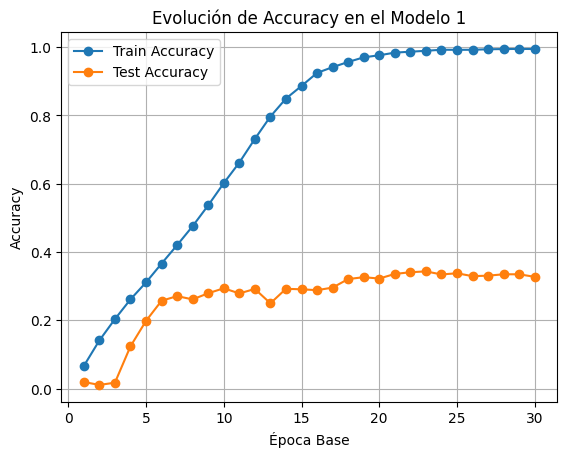

Distribución de clases añadidas en el modelo 1: {np.int64(0): np.int64(111), np.int64(1): np.int64(41), np.int64(2): np.int64(9), np.int64(3): np.int64(17), np.int64(4): np.int64(45), np.int64(5): np.int64(27), np.int64(6): np.int64(13), np.int64(7): np.int64(49), np.int64(8): np.int64(86), np.int64(9): np.int64(73), np.int64(10): np.int64(40), np.int64(11): np.int64(35), np.int64(12): np.int64(42), np.int64(13): np.int64(20), np.int64(14): np.int64(22), np.int64(15): np.int64(2), np.int64(16): np.int64(76), np.int64(17): np.int64(68), np.int64(18): np.int64(17), np.int64(19): np.int64(17), np.int64(20): np.int64(133), np.int64(21): np.int64(86), np.int64(22): np.int64(40), np.int64(23): np.int64(123), np.int64(24): np.int64(117), np.int64(25): np.int64(19), np.int64(26): np.int64(41), np.int64(27): np.int64(8), np.int64(28): np.int64(98), np.int64(29): np.int64(74), np.int64(30): np.int64(150), np.int64(31): np.int64(50), np.int64(32): np.int64(23), np.int64(33): np.int64(49), np.int6

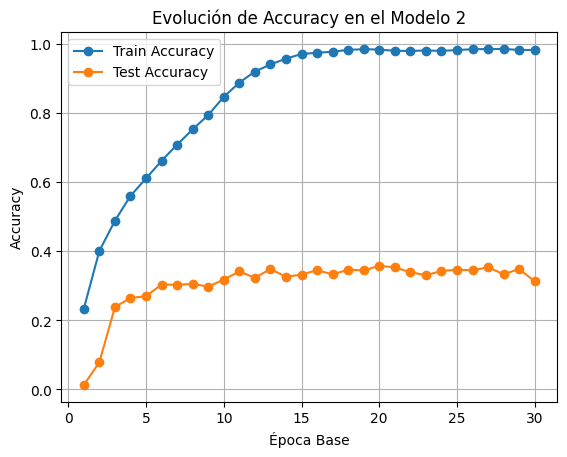

Distribución de clases añadidas en el modelo 2: {np.int64(0): np.int64(213), np.int64(1): np.int64(52), np.int64(2): np.int64(6), np.int64(3): np.int64(75), np.int64(4): np.int64(90), np.int64(5): np.int64(144), np.int64(6): np.int64(20), np.int64(7): np.int64(213), np.int64(8): np.int64(62), np.int64(9): np.int64(35), np.int64(10): np.int64(48), np.int64(11): np.int64(21), np.int64(12): np.int64(31), np.int64(13): np.int64(25), np.int64(14): np.int64(16), np.int64(15): np.int64(71), np.int64(16): np.int64(33), np.int64(17): np.int64(75), np.int64(18): np.int64(3), np.int64(19): np.int64(4), np.int64(20): np.int64(69), np.int64(21): np.int64(77), np.int64(22): np.int64(12), np.int64(23): np.int64(144), np.int64(24): np.int64(6), np.int64(25): np.int64(35), np.int64(26): np.int64(60), np.int64(27): np.int64(62), np.int64(28): np.int64(96), np.int64(29): np.int64(85), np.int64(30): np.int64(165), np.int64(31): np.int64(149), np.int64(32): np.int64(18), np.int64(33): np.int64(101), np.int

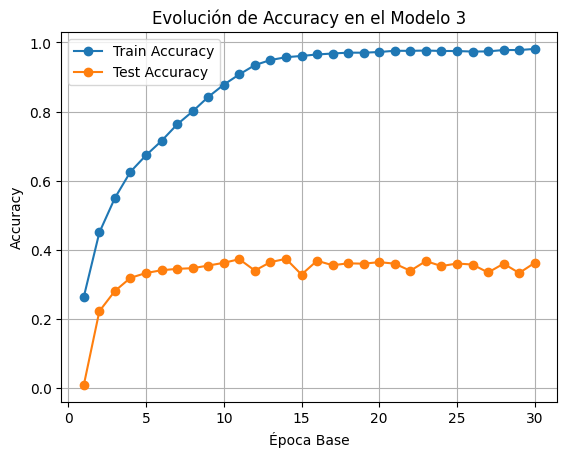

Distribución de clases añadidas en el modelo 3: {np.int64(0): np.int64(57), np.int64(1): np.int64(30), np.int64(2): np.int64(16), np.int64(3): np.int64(25), np.int64(4): np.int64(76), np.int64(5): np.int64(102), np.int64(6): np.int64(20), np.int64(7): np.int64(136), np.int64(8): np.int64(50), np.int64(9): np.int64(72), np.int64(10): np.int64(73), np.int64(11): np.int64(19), np.int64(12): np.int64(71), np.int64(13): np.int64(58), np.int64(14): np.int64(17), np.int64(15): np.int64(44), np.int64(16): np.int64(28), np.int64(17): np.int64(180), np.int64(18): np.int64(17), np.int64(19): np.int64(15), np.int64(20): np.int64(71), np.int64(21): np.int64(84), np.int64(22): np.int64(27), np.int64(23): np.int64(119), np.int64(24): np.int64(40), np.int64(25): np.int64(37), np.int64(26): np.int64(126), np.int64(27): np.int64(33), np.int64(28): np.int64(38), np.int64(29): np.int64(164), np.int64(30): np.int64(56), np.int64(31): np.int64(237), np.int64(32): np.int64(27), np.int64(33): np.int64(46), np

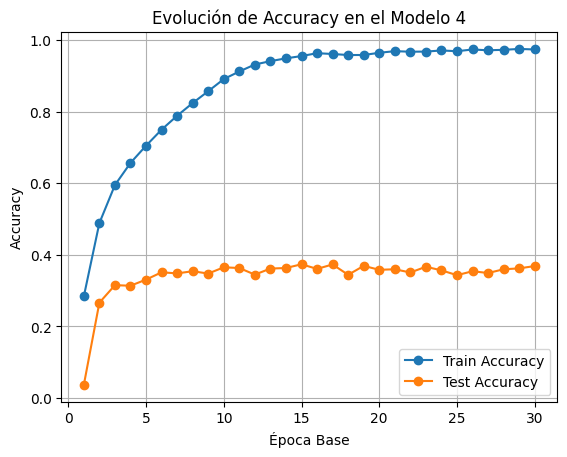

Distribución de clases añadidas en el modelo 4: {np.int64(0): np.int64(29), np.int64(1): np.int64(72), np.int64(2): np.int64(9), np.int64(3): np.int64(13), np.int64(4): np.int64(41), np.int64(5): np.int64(72), np.int64(6): np.int64(32), np.int64(7): np.int64(40), np.int64(8): np.int64(37), np.int64(9): np.int64(36), np.int64(10): np.int64(48), np.int64(11): np.int64(33), np.int64(12): np.int64(58), np.int64(13): np.int64(28), np.int64(14): np.int64(30), np.int64(15): np.int64(14), np.int64(16): np.int64(12), np.int64(17): np.int64(26), np.int64(18): np.int64(28), np.int64(19): np.int64(7), np.int64(20): np.int64(60), np.int64(21): np.int64(75), np.int64(22): np.int64(31), np.int64(23): np.int64(49), np.int64(24): np.int64(45), np.int64(25): np.int64(30), np.int64(26): np.int64(39), np.int64(27): np.int64(60), np.int64(28): np.int64(41), np.int64(29): np.int64(36), np.int64(30): np.int64(87), np.int64(31): np.int64(35), np.int64(32): np.int64(9), np.int64(33): np.int64(39), np.int64(34)

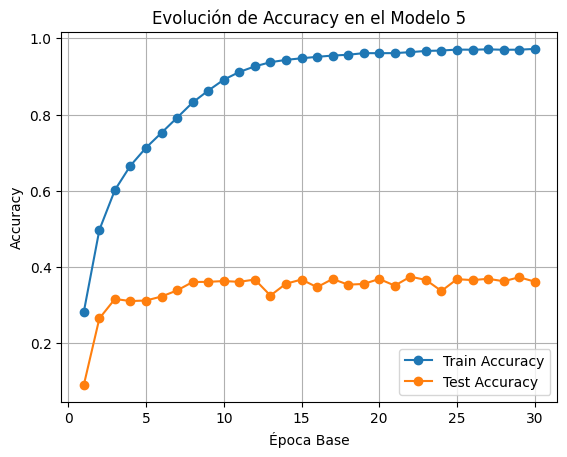

Distribución de clases añadidas en el modelo 5: {np.int64(0): np.int64(39), np.int64(1): np.int64(66), np.int64(2): np.int64(11), np.int64(3): np.int64(25), np.int64(4): np.int64(35), np.int64(5): np.int64(20), np.int64(6): np.int64(15), np.int64(7): np.int64(85), np.int64(8): np.int64(13), np.int64(9): np.int64(9), np.int64(10): np.int64(30), np.int64(11): np.int64(3), np.int64(12): np.int64(25), np.int64(13): np.int64(23), np.int64(14): np.int64(11), np.int64(15): np.int64(27), np.int64(16): np.int64(10), np.int64(17): np.int64(74), np.int64(18): np.int64(13), np.int64(19): np.int64(3), np.int64(20): np.int64(20), np.int64(21): np.int64(100), np.int64(22): np.int64(12), np.int64(23): np.int64(41), np.int64(24): np.int64(40), np.int64(25): np.int64(19), np.int64(26): np.int64(28), np.int64(27): np.int64(18), np.int64(28): np.int64(22), np.int64(29): np.int64(27), np.int64(30): np.int64(157), np.int64(31): np.int64(33), np.int64(32): np.int64(10), np.int64(33): np.int64(55), np.int64(3

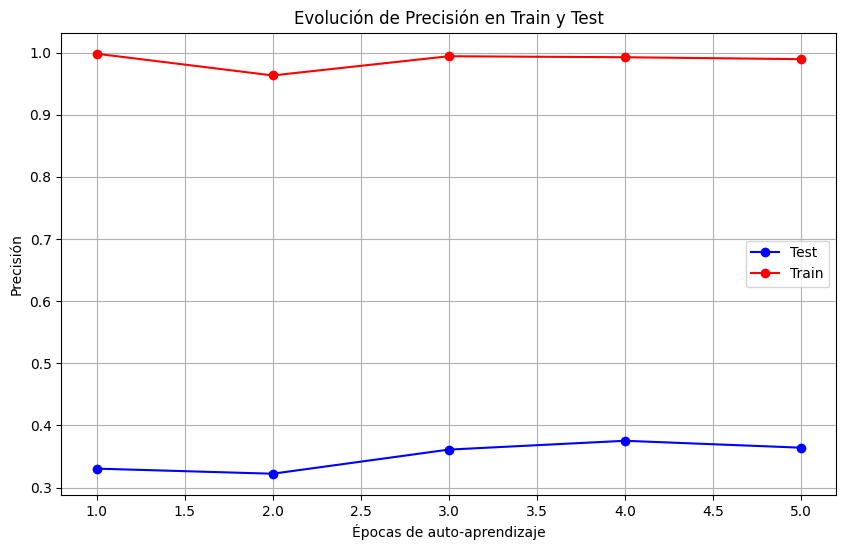

In [ ]:
# *** Entrenamiento final con parámetros ajustados
best_model, test_scores, train_scores = self_training_v2(
    MiClasificador,
    x_train_labeled,
    y_train_labeled,
    x_train_unlabeled,
    x_test_labeled,
    y_test_labeled,
    epochs_base= 30,
    thresh=0.95,
    num_modelos=5
)

# Evaluación final
_, final_acc = best_model.model.evaluate(x_test_labeled, y_test_labeled)
print(f"\nPrecisión final: {final_acc:.4f}")

# Gráfico de evolución
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(test_scores)+1), test_scores, 'bo-', label='Test')
plt.plot(range(1, len(train_scores)+1), train_scores, 'ro-', label='Train')  # Nueva línea
plt.xlabel('Épocas de auto-aprendizaje')
plt.ylabel('Precisión')
plt.title('Evolución de Precisión en Train y Test')
plt.legend()
plt.grid(True)
plt.show()

# Ejercicio 3

In [ ]:
# Opcional: Combinar datos para el autoencoder (usamos todas las imágenes disponibles)
x_train_ae = np.concatenate([x_train_unlabeled, x_train_labeled], axis=0)

In [ ]:
class AutoencoderCNN:
    def __init__(self, input_shape=(32, 32, 3)):
        self.input_shape = input_shape
        self.encoder = self.build_encoder()
        self.decoder = self.build_decoder(self.encoder.output_shape[1:])
        self.autoencoder = self.build_autoencoder()

    def build_encoder(self):
        inputs = Input(shape=self.input_shape)

        # Bloque 1
        x = Conv2D(64, (3,3), activation='relu', padding='same',
                   kernel_regularizer=regularizers.l2(1e-4))(inputs)
        x = BatchNormalization()(x)
        x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
        x = MaxPooling2D((2,2))(x)
        x = Dropout(0.2)(x)

        # Bloque 2
        x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
        x = BatchNormalization()(x)
        x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
        x = MaxPooling2D((2,2))(x)
        x = Dropout(0.2)(x)

        # Bloque 3
        x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
        x = BatchNormalization()(x)
        x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
        x = MaxPooling2D((2,2))(x)
        encoded = Dropout(0.2)(x)

        return Model(inputs, encoded, name="encoder")

    def build_decoder(self, encoded_shape):
        encoded_input = Input(shape=encoded_shape)

        x = UpSampling2D((2,2))(encoded_input)
        x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
        x = BatchNormalization()(x)

        x = UpSampling2D((2,2))(x)
        x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
        x = BatchNormalization()(x)

        x = UpSampling2D((2,2))(x)
        x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
        x = BatchNormalization()(x)

        decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

        return Model(encoded_input, decoded, name="decoder")

    def build_autoencoder(self):
        input_img = Input(shape=self.input_shape)
        encoded = self.encoder(input_img)
        decoded = self.decoder(encoded)
        return Model(input_img, decoded, name="autoencoder")


In [ ]:
class ClassifierWithEncoder:
    def __init__(self, encoder, num_classes=100, freeze_encoder=False):
        self.encoder = encoder
        self.num_classes = num_classes
        self.freeze_encoder = freeze_encoder

        if self.freeze_encoder:
            for layer in self.encoder.layers:
                layer.trainable = False

        self.classifier = self.build_classifier()

    def build_classifier(self):
        x = self.encoder.output
        x = Flatten()(x)
        x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
        x = BatchNormalization()(x)
        x = Dropout(0.2)(x)
        output = Dense(self.num_classes, activation='softmax')(x)

        return Model(self.encoder.input, output, name="classifier")


In [ ]:
# Crear autoencoder
ae = AutoencoderCNN()

# Compilar
ae.autoencoder.compile(optimizer=Adam(), loss='mse')

# Entrenar con imágenes combinadas (etiquetadas + no etiquetadas)
history_ae = ae.autoencoder.fit(
    x_train_ae, x_train_ae,
    epochs=15,
    batch_size=128,
    validation_data=(x_val, x_val),
    verbose=1
)




# Construir el clasificador usando el encoder ya entrenado del autoencoder
clf = ClassifierWithEncoder(encoder=ae.encoder)

# Compilar con AdamW y weight decay
clf.classifier.compile(
    loss='categorical_crossentropy',
    optimizer=AdamW(learning_rate=3e-4, weight_decay=1e-4),
    metrics=['accuracy']
)

# Entrenar solo con el 20% de datos etiquetados
history_cls = clf.classifier.fit(
    x_train_labeled, y_train_labeled,
    batch_size=128,
    epochs=20,
    validation_data=(x_val, y_val),
    verbose=1
)


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 36s 65ms/step - loss: 0.0193 - val_loss: 0.0360
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 35s 62ms/step - loss: 0.0076 - val_loss: 0.0063
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - loss: 0.0064 - val_loss: 0.0048
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - loss: 0.0058 - val_loss: 0.0067
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - loss: 0.0054 - val_loss: 0.0042
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - loss: 0.0052 - val_loss: 0.0041
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - loss: 0.0050 - val_loss: 0.0041
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - loss: 0.0048 - val_loss: 0.0036
Epoch 9/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - loss: 0.0046 - val_loss: 0.0035
Epoch 10/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - loss: 0.0044 - val_loss: 0.0034
Epoch 11/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - loss: 0.0043 - val_loss: 0.0034
Epoch 12/15
375/375 ━━━━━━━━━━

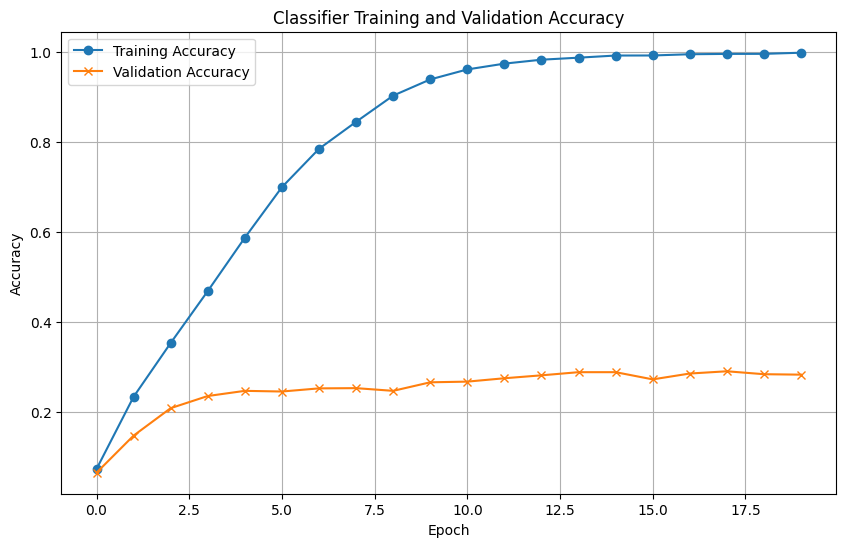

In [ ]:
plt.figure(figsize=(10, 6))

# Plot with lines and markers for Training Accuracy
plt.plot(history_cls.history['accuracy'], label='Training Accuracy', marker='o')

# Plot with lines and markers for Validation Accuracy
plt.plot(history_cls.history['val_accuracy'], label='Validation Accuracy', marker='x')

plt.title('Classifier Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluar pérdida de reconstrucción en validación
loss_ae = ae.autoencoder.evaluate(x_val, x_val, verbose=0)
print(f"[Autoencoder] Pérdida de reconstrucción (MSE) en validación: {loss_ae:.4f}")

# Evaluación en el conjunto de prueba
test_loss, test_acc = clf.classifier.evaluate(x_test_labeled, y_test_labeled, verbose=0)

print(f"[Clasificador] Pérdida en test: {test_loss:.4f}")
print(f"[Clasificador] Precisión en test: {test_acc:.4f}")

[Autoencoder] Pérdida de reconstrucción (MSE) en validación: 0.0237
[Clasificador] Pérdida en test: 3.3139
[Clasificador] Precisión en test: 0.3017


#Ejercicio 5

####5.2

In [ ]:
class ChangeRCallback(tf.keras.callbacks.Callback):
   def __init__(self, train_data, delta=.025, steps=3):
       super().__init__()
       self.train_data = train_data
       self.delta = delta
       self.steps = steps
       self.cont = 0

   def on_epoch_end(self, epoch, logs=None):
       sorted_values = np.sort(self.model.predict(self.train_data).flatten())
       new_value = sorted_values[int(len(sorted_values) * (1. - self.model.nu))]
       old_value = self.model.r.numpy()
       print('Cambiando r a', new_value, ', max:', sorted_values.max(), ', min:', sorted_values.min())
       self.model.r.assign(new_value)
       if np.abs(old_value - new_value) < self.delta:
            self.cont += 1
            if self.cont >= self.steps:
                print('Convergencia obtenida. Finalizando el entrenamiento.')
                self.model.stop_training = True
       else:
            self.cont = 0

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Cambiando r a -52.502136 , max: -34.965256 , min: -55.911144
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cambiando r a -59.440544 , max: -23.130684 , min: -70.94169
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cambiando r a -44.92138 , max: 12.680779 , min: -63.762264
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cambiando r a -27.903147 , max: 65.73713 , min: -53.70639
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cambiando r a -13.598762 , max: 108.39492 , min: -42.624783
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cambiando r a -0.48818946 , max: 136.55016 , min: -33.85717
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cambiando r a 7.932428 , max: 148.8465 , min: -32.158607
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cambiando r a 15.215516 , max: 163.69142 , min: -20.419687
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cambiando r a 23.295664 , max: 234.4874 , min: -20.49372
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Cambiando r a 31.16839 , max: 299.34412 , min: -16.469835
2

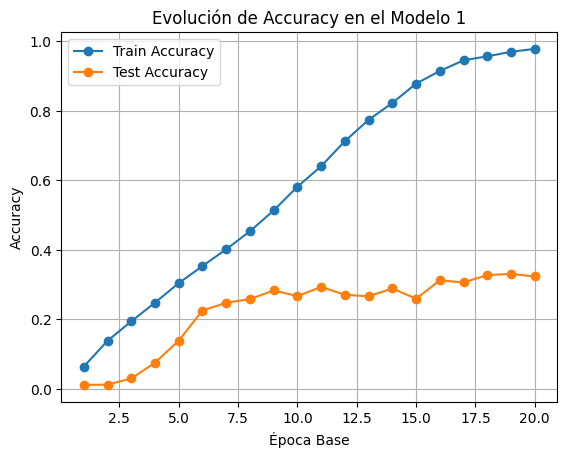

Distribución de clases añadidas en el modelo 1: {np.int64(0): np.int64(90), np.int64(1): np.int64(20), np.int64(2): np.int64(35), np.int64(3): np.int64(5), np.int64(4): np.int64(8), np.int64(5): np.int64(56), np.int64(6): np.int64(39), np.int64(7): np.int64(53), np.int64(8): np.int64(71), np.int64(9): np.int64(64), np.int64(10): np.int64(12), np.int64(11): np.int64(13), np.int64(12): np.int64(27), np.int64(13): np.int64(2), np.int64(14): np.int64(14), np.int64(15): np.int64(4), np.int64(16): np.int64(54), np.int64(17): np.int64(19), np.int64(18): np.int64(9), np.int64(19): np.int64(13), np.int64(20): np.int64(138), np.int64(21): np.int64(67), np.int64(22): np.int64(47), np.int64(23): np.int64(56), np.int64(24): np.int64(150), np.int64(25): np.int64(4), np.int64(26): np.int64(48), np.int64(27): np.int64(11), np.int64(28): np.int64(65), np.int64(29): np.int64(26), np.int64(30): np.int64(107), np.int64(31): np.int64(18), np.int64(32): np.int64(3), np.int64(33): np.int64(29), np.int64(34):

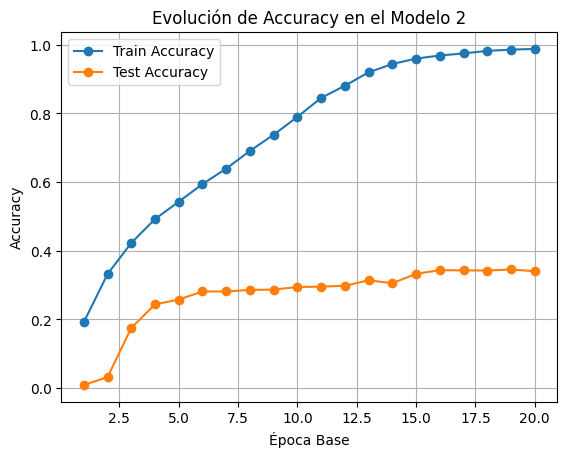

Distribución de clases añadidas en el modelo 2: {np.int64(0): np.int64(36), np.int64(1): np.int64(37), np.int64(2): np.int64(18), np.int64(3): np.int64(36), np.int64(4): np.int64(17), np.int64(5): np.int64(47), np.int64(6): np.int64(14), np.int64(7): np.int64(33), np.int64(8): np.int64(19), np.int64(9): np.int64(48), np.int64(10): np.int64(12), np.int64(11): np.int64(13), np.int64(12): np.int64(21), np.int64(13): np.int64(27), np.int64(14): np.int64(31), np.int64(15): np.int64(13), np.int64(16): np.int64(15), np.int64(17): np.int64(32), np.int64(18): np.int64(12), np.int64(19): np.int64(11), np.int64(20): np.int64(102), np.int64(21): np.int64(28), np.int64(22): np.int64(23), np.int64(23): np.int64(60), np.int64(24): np.int64(85), np.int64(25): np.int64(19), np.int64(26): np.int64(49), np.int64(27): np.int64(11), np.int64(28): np.int64(58), np.int64(29): np.int64(42), np.int64(30): np.int64(160), np.int64(31): np.int64(37), np.int64(32): np.int64(19), np.int64(33): np.int64(12), np.int6

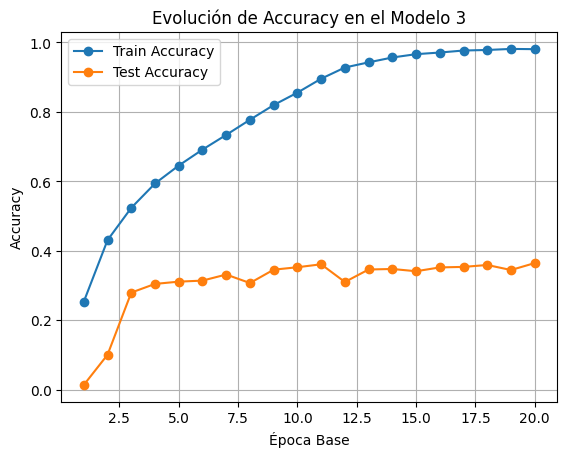

Distribución de clases añadidas en el modelo 3: {np.int64(0): np.int64(94), np.int64(1): np.int64(32), np.int64(2): np.int64(1), np.int64(3): np.int64(43), np.int64(4): np.int64(22), np.int64(5): np.int64(43), np.int64(6): np.int64(37), np.int64(7): np.int64(75), np.int64(8): np.int64(22), np.int64(9): np.int64(31), np.int64(10): np.int64(11), np.int64(11): np.int64(7), np.int64(12): np.int64(10), np.int64(13): np.int64(13), np.int64(14): np.int64(105), np.int64(15): np.int64(11), np.int64(16): np.int64(7), np.int64(17): np.int64(38), np.int64(18): np.int64(54), np.int64(19): np.int64(34), np.int64(20): np.int64(58), np.int64(21): np.int64(19), np.int64(22): np.int64(18), np.int64(23): np.int64(46), np.int64(24): np.int64(72), np.int64(25): np.int64(11), np.int64(26): np.int64(33), np.int64(27): np.int64(36), np.int64(28): np.int64(51), np.int64(29): np.int64(61), np.int64(30): np.int64(62), np.int64(31): np.int64(21), np.int64(32): np.int64(16), np.int64(33): np.int64(30), np.int64(34

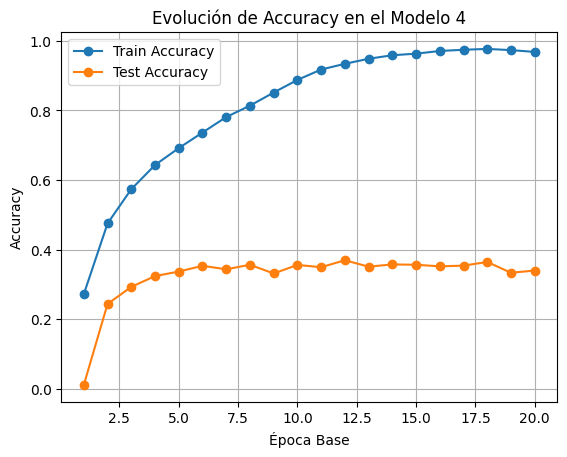

Distribución de clases añadidas en el modelo 4: {np.int64(0): np.int64(69), np.int64(1): np.int64(65), np.int64(2): np.int64(18), np.int64(3): np.int64(3), np.int64(4): np.int64(18), np.int64(5): np.int64(40), np.int64(6): np.int64(4), np.int64(7): np.int64(57), np.int64(8): np.int64(16), np.int64(9): np.int64(25), np.int64(10): np.int64(6), np.int64(11): np.int64(21), np.int64(12): np.int64(15), np.int64(13): np.int64(8), np.int64(14): np.int64(5), np.int64(15): np.int64(4), np.int64(16): np.int64(10), np.int64(17): np.int64(10), np.int64(18): np.int64(4), np.int64(19): np.int64(3), np.int64(20): np.int64(57), np.int64(21): np.int64(19), np.int64(22): np.int64(11), np.int64(23): np.int64(84), np.int64(24): np.int64(94), np.int64(25): np.int64(15), np.int64(26): np.int64(29), np.int64(27): np.int64(75), np.int64(28): np.int64(71), np.int64(29): np.int64(13), np.int64(30): np.int64(164), np.int64(31): np.int64(50), np.int64(32): np.int64(4), np.int64(33): np.int64(6), np.int64(34): np.i

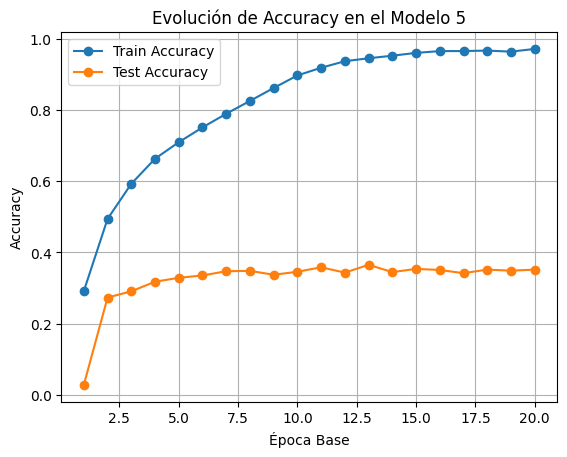

Distribución de clases añadidas en el modelo 5: {np.int64(0): np.int64(40), np.int64(1): np.int64(36), np.int64(2): np.int64(4), np.int64(3): np.int64(41), np.int64(4): np.int64(16), np.int64(5): np.int64(29), np.int64(6): np.int64(23), np.int64(7): np.int64(41), np.int64(8): np.int64(6), np.int64(9): np.int64(23), np.int64(10): np.int64(13), np.int64(11): np.int64(8), np.int64(12): np.int64(4), np.int64(13): np.int64(27), np.int64(14): np.int64(73), np.int64(15): np.int64(21), np.int64(16): np.int64(8), np.int64(17): np.int64(7), np.int64(18): np.int64(25), np.int64(19): np.int64(10), np.int64(20): np.int64(27), np.int64(21): np.int64(26), np.int64(22): np.int64(11), np.int64(23): np.int64(35), np.int64(24): np.int64(86), np.int64(25): np.int64(18), np.int64(26): np.int64(10), np.int64(27): np.int64(44), np.int64(28): np.int64(25), np.int64(29): np.int64(18), np.int64(30): np.int64(61), np.int64(31): np.int64(18), np.int64(32): np.int64(18), np.int64(33): np.int64(2), np.int64(34): np

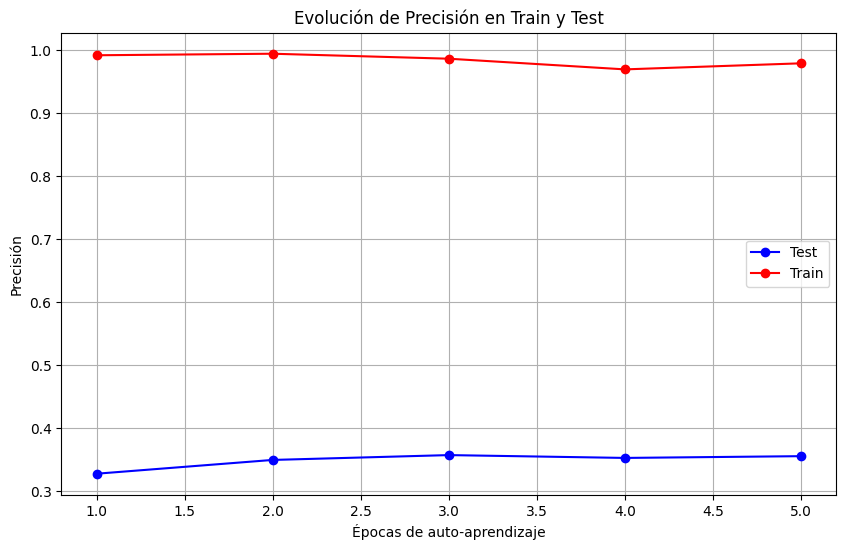

In [ ]:
# Entrenar detector de anomalías usando datos etiquetados como normales
class DetectorAnomaliasCIFAR:
    def __init__(self, input_shape=(32,32,3), nu=0.1):
        # Arquitectura similar al clasificador pero con salida lineal
        inputs = tf.keras.Input(shape=input_shape)

        x = Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
        x = BatchNormalization()(x)
        x = MaxPooling2D((2,2))(x)
        x = Dropout(0.2)(x)

        x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
        x = BatchNormalization()(x)
        x = MaxPooling2D((2,2))(x)
        x = Dropout(0.2)(x)

        x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
        x = BatchNormalization()(x)
        x = MaxPooling2D((2,2))(x)
        x = Dropout(0.2)(x)

        x = Flatten()(x)
        x = Dense(512, activation='relu')(x)
        outputs = Dense(1)(x)  # Salida lineal para detección de anomalías

        self.model = tf.keras.Model(inputs=inputs, outputs=outputs)
        self.model.r = tf.Variable(1.0, trainable=False, name='r')
        self.model.nu = tf.Variable(nu, trainable=False, name='nu')
        self.model.compile(optimizer='adam', loss=self.loss_function)

    def loss_function(self, y_true, y_pred):
        margin = tf.maximum(0.0, self.model.r - y_pred)
        return (1.0/self.model.nu) * tf.reduce_mean(margin)

    def fit(self, X, epochs=20, batch_size=128):
        callback = ChangeRCallback(X)
        dummy_y = np.zeros((len(X), 1))
        self.model.fit(X, dummy_y, epochs=epochs, batch_size=batch_size, callbacks=[callback], verbose=0)

    def predict(self, X):
        return self.model.predict(X).flatten() > self.model.r.numpy()

# Entrenar detector con ν=0.9 para eliminar 10% más atípico
detector = DetectorAnomaliasCIFAR(nu=0.9)
detector.fit(x_train_labeled, epochs=20)

#  Filtrar datos no etiquetados
scores_unlabeled = detector.model.predict(x_train_unlabeled).flatten()
umbral = np.quantile(scores_unlabeled, 0.1)  # ν=0.9 eliminar 10% inferior
mask = scores_unlabeled > umbral
x_train_unlabeled_filtrado = x_train_unlabeled[mask]
print("Datos detectados como atípicos: ", len(x_train_unlabeled)- len(x_train_unlabeled_filtrado))

# PASO 3: Autoaprendizaje con datos filtrados
def self_training_v3(model_func, x_train, y_train, unlabeled_data, x_test, y_test,
                    epochs_base=20, thresh=0.95, num_modelos=5):

    train_data = x_train.copy()
    train_label = y_train.copy()
    current_unlabeled = unlabeled_data.copy()

    sample_weights = np.ones(len(train_label))
    test_scores = []  # Precisión en test al final de cada modelo
    train_scores = []  # Precisión en train al final de cada modelo
    best_score = 0
    best_model = None

    print(f"Inicio: {len(train_data)} ejemplos etiquetados, {len(current_unlabeled)} sin etiquetar")

    for train_epoch in range(num_modelos):
        model = model_func()

        # Entrenar el modelo durante 'epochs_base' épocas y almacenar el historial
        history = model.fit(train_data, train_label, epochs_base=epochs_base, sample_weight=sample_weights)

        # Extraer las métricas de entrenamiento y validación para cada epoch_base
        train_history = history.history['accuracy']
        test_history = history.history['val_accuracy']

        # Graficar la evolución de accuracy durante las epochs_base de este modelo
        plt.figure()
        plt.plot(range(1, epochs_base+1), train_history, marker='o', label='Train Accuracy')
        plt.plot(range(1, epochs_base+1), test_history, marker='o', label='Test Accuracy')
        plt.xlabel('Época Base')
        plt.ylabel('Accuracy')
        plt.title(f'Evolución de Accuracy en el Modelo {train_epoch+1}')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Calcular la precisión final del modelo entrenado
        final_train_acc = model.score(train_data, train_label)
        final_test_acc = model.score(x_test, y_test)

        train_scores.append(final_train_acc)
        test_scores.append(final_test_acc)

        if final_test_acc > best_score:
            best_score = final_test_acc
            best_model = model

        # Generar pseudo-etiquetas
        y_proba = model.predict_proba(current_unlabeled)
        y_conf = np.max(y_proba, axis=1)
        y_pred = np.argmax(y_proba, axis=1)

        # Selección conservadora de pseudo-etiquetas
        high_conf = y_conf > thresh
        x_new = current_unlabeled[high_conf]
        y_new = to_categorical(y_pred[high_conf], num_classes=100)
        confidences = y_conf[high_conf]

        if len(x_new) > 0:
            # Se añaden los nuevos ejemplos (x_new) al conjunto de entrenamiento existente
            train_data = np.concatenate([train_data, x_new], axis=0)
            # Se añaden las pseudo-etiquetas correspondientes (y_new) al conjunto de etiquetas existente
            train_label = np.concatenate([train_label, y_new], axis=0)

            # Se actualizan los pesos de entrenamiento:
            # Los nuevos pesos se establecen igual a la confianza del modelo en cada ejemplo,
            # en lugar de utilizar el cuadrado de la confianza.
            new_weights = np.concatenate([sample_weights, confidences])
            sample_weights = new_weights

            # Se eliminan de los datos sin etiquetar los ejemplos que ya se han añadido al entrenamiento
            current_unlabeled = current_unlabeled[~high_conf]


            # Balancear clases (muestreo estratificado aproximado)
            unique, counts = np.unique(y_pred[high_conf], return_counts=True)
            class_distribution = dict(zip(unique, counts))
            print(f"Distribución de clases añadidas en el modelo {train_epoch+1}: {class_distribution}")

        print(f"Modelo {train_epoch+1}: Train Acc final={final_train_acc:.4f}, Test Acc final={final_test_acc:.4f}, "
              f"Etiquetados={len(train_data)}, Sin etiquetar={len(current_unlabeled)}")

        if len(current_unlabeled) == 0:
            print("¡Todos los datos etiquetados!")
            break

    return best_model, test_scores, train_scores


# Entrenamiento final
best_model, test_scores, train_scores = self_training_v3(
    MiClasificador,
    x_train_labeled,
    y_train_labeled,
    x_train_unlabeled_filtrado,  # Usar datos filtrados
    x_test_labeled,
    y_test_labeled,
    epochs_base=20,
    thresh=0.95,
    num_modelos=5
)

# Evaluación y gráficos (igual que antes)
_, final_acc = best_model.model.evaluate(x_test_labeled, y_test_labeled)
print(f"\nPrecisión final: {final_acc:.4f}")

# Gráfico de evolución
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(test_scores)+1), test_scores, 'bo-', label='Test')
plt.plot(range(1, len(train_scores)+1), train_scores, 'ro-', label='Train')  # Nueva línea
plt.xlabel('Épocas de auto-aprendizaje')
plt.ylabel('Precisión')
plt.title('Evolución de Precisión en Train y Test')
plt.legend()
plt.grid(True)
plt.show()

#### 5.3

In [ ]:
class DetectorAnomaliasCIFAR:
    def __init__(self, input_shape=(32,32,3), nu=0.1):
        # Arquitectura similar al clasificador del Ejercicio 1 (encoder)
        inputs = tf.keras.Input(shape=input_shape)

        x = Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
        x = BatchNormalization()(x)
        x = MaxPooling2D((2,2))(x)
        x = Dropout(0.2)(x)

        x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
        x = BatchNormalization()(x)
        x = MaxPooling2D((2,2))(x)
        x = Dropout(0.2)(x)

        x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
        x = BatchNormalization()(x)
        x = MaxPooling2D((2,2))(x)
        x = Flatten()(x)

        outputs = Dense(1)(x)  # Salida lineal

        self.model = tf.keras.Model(inputs=inputs, outputs=outputs)
        self.model.r = tf.Variable(1.0, trainable=False, name='r')
        self.model.nu = tf.Variable(nu, trainable=False, name='nu')
        self.model.compile(optimizer='adam', loss=self.loss_function)

    def loss_function(self, y_true, y_pred):
        margin = tf.maximum(0.0, self.model.r - y_pred)
        return (1.0/self.model.nu) * tf.reduce_mean(margin)

    def fit(self, X, epochs=15, batch_size=128):
        callback = ChangeRCallback(X)
        dummy_y = np.zeros((len(X), 1))
        self.model.fit(X, dummy_y, epochs=epochs, batch_size=batch_size, callbacks=[callback], verbose=0)

    def predict_scores(self, X):
        return self.model.predict(X).flatten()

# Entrenar detector con ν=0.9 (eliminar 10% atípico)
detector = DetectorAnomaliasCIFAR(nu=0.9)
detector.fit(x_train_labeled, epochs=15)

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Cambiando r a -4.2205057 , max: -2.1456318 , min: -4.7031307
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cambiando r a -5.679027 , max: -2.0395708 , min: -6.6770353
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cambiando r a -5.460305 , max: 0.46940896 , min: -7.106365
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cambiando r a -4.6785254 , max: 4.1035013 , min: -6.70343
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cambiando r a -3.5497262 , max: 8.4331255 , min: -6.210099
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Cambiando r a -2.2390106 , max: 14.855962 , min: -5.2219114
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cambiando r a -0.65545833 , max: 22.376556 , min: -4.1559234
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cambiando r a 1.2736968 , max: 29.8595 , min: -3.2417347
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cambiando r a 3.551637 , max: 36.6614 , min: -2.4208386
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cambiando r a 5.9399366 , max: 42.21926 , min: -1.4617926
2

In [ ]:
# Calcular puntuaciones y umbral
scores_unlabeled = detector.predict_scores(x_train_unlabeled)
umbral = np.quantile(scores_unlabeled, 0.1)  # ν=0.9 → percentil 10%
mask = scores_unlabeled > umbral
x_train_unlabeled_filtrado = x_train_unlabeled[mask]

print(f"Datos no etiquetados restantes: {len(x_train_unlabeled_filtrado)}/{len(x_train_unlabeled)}")

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Datos no etiquetados restantes: 36000/40000


In [ ]:
# Combinar datos etiquetados + no etiquetados filtrados
x_train_ae = np.concatenate([x_train_unlabeled_filtrado, x_train_labeled], axis=0)

# Crear y entrenar autoencoder (misma implementación del Ejercicio 3)
ae = AutoencoderCNN()
ae.autoencoder.compile(optimizer=Adam(), loss='mse')
history_ae = ae.autoencoder.fit(
    x_train_ae, x_train_ae,
    epochs=15,
    batch_size=128,
    validation_data=(x_val, x_val),
    verbose=1
)

Epoch 1/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 38s 79ms/step - loss: 0.0214 - val_loss: 0.0332
Epoch 2/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - loss: 0.0080 - val_loss: 0.0077
Epoch 3/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - loss: 0.0065 - val_loss: 0.0056
Epoch 4/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - loss: 0.0059 - val_loss: 0.0057
Epoch 5/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 6/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - loss: 0.0054 - val_loss: 0.0044
Epoch 7/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - loss: 0.0050 - val_loss: 0.0049
Epoch 8/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - loss: 0.0049 - val_loss: 0.0040
Epoch 9/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - loss: 0.0047 - val_loss: 0.0040
Epoch 10/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - loss: 0.0045 - val_loss: 0.0045
Epoch 11/15
344/344 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - loss: 0.0044 - val_loss: 0.0040
Epoch 12/15
344/344 ━━━━━━━━━━

In [ ]:
# Construir clasificador usando el encoder del autoencoder
clf = ClassifierWithEncoder(encoder=ae.encoder, freeze_encoder=False)
clf.classifier.compile(
    loss='categorical_crossentropy',
    optimizer=AdamW(learning_rate=3e-4, weight_decay=1e-4),
    metrics=['accuracy']
)

# Entrenar solo con datos etiquetados
history_cls = clf.classifier.fit(
    x_train_labeled, y_train_labeled,
    batch_size=128,
    epochs=20,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - accuracy: 0.0462 - loss: 5.0317 - val_accuracy: 0.0855 - val_loss: 4.9744
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.2398 - loss: 3.3191 - val_accuracy: 0.1790 - val_loss: 3.7367
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.3714 - loss: 2.6823 - val_accuracy: 0.2090 - val_loss: 3.4501
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5021 - loss: 2.1429 - val_accuracy: 0.2525 - val_loss: 3.2624
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.6026 - loss: 1.7364 - val_accuracy: 0.2455 - val_loss: 3.2593
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7146 - loss: 1.3592 - val_accuracy: 0.2640 - val_loss: 3.2082
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.7945 - loss: 1.0678 - val_accuracy: 0.2580 - val_loss: 3.2267
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8622 - loss: 0.8210 - val_accuracy: 0.2545 -

In [ ]:
# Evaluar reconstrucción
loss_ae = ae.autoencoder.evaluate(x_val, x_val, verbose=0)
print(f"[Autoencoder] MSE en validación: {loss_ae:.4f}")

# Evaluar clasificador
test_loss, test_acc = clf.classifier.evaluate(x_test_labeled, y_test_labeled, verbose=0)
print(f"[Clasificador] Precisión en test: {test_acc:.4f}")

[Autoencoder] MSE en validación: 0.0223
[Clasificador] Precisión en test: 0.2976


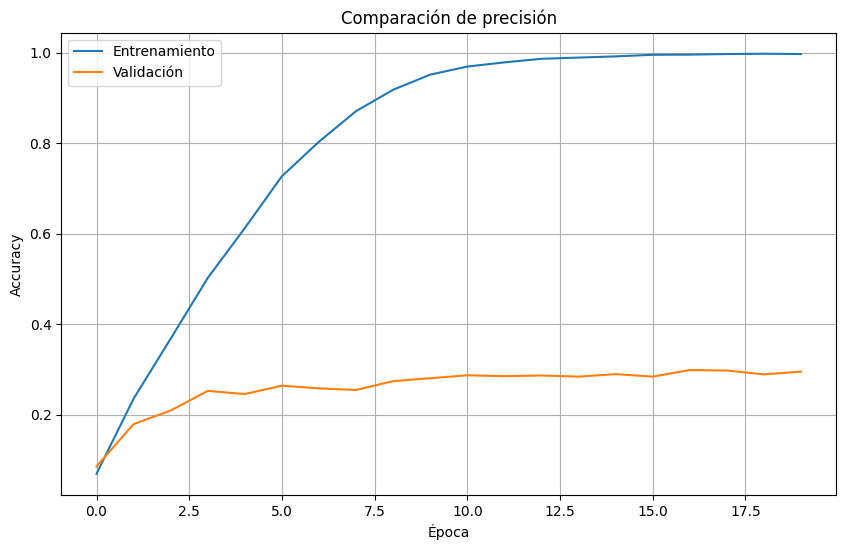

In [ ]:
# Comparación de precisión
plt.figure(figsize=(10,6))

# Graficar precisión en entrenamiento
plt.plot(history_cls.history['accuracy'], label='Entrenamiento')

# Graficar precisión en validación
plt.plot(history_cls.history['val_accuracy'], label='Validación')

plt.title('Comparación de precisión')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


# Ejercicio 6

####Ejercicio 6.3

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.optimizers import AdamW
import numpy as np

# 1. Encoder IDÉNTICO al del autoencoder original
class ConvEncoder(tf.keras.Model):
    def __init__(self):
        super(ConvEncoder, self).__init__()

        # Bloque 1 (idéntico)
        self.conv1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')
        self.bn1 = layers.BatchNormalization()
        self.conv2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')
        self.pool1 = layers.MaxPooling2D((2,2))
        self.drop1 = layers.Dropout(0.2)

        # Bloque 2 (idéntico)
        self.conv3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')
        self.bn2 = layers.BatchNormalization()
        self.conv4 = layers.Conv2D(128, (3,3), activation='relu', padding='same')
        self.pool2 = layers.MaxPooling2D((2,2))
        self.drop2 = layers.Dropout(0.2)

        # Bloque 3 (idéntico al original)
        self.conv5 = layers.Conv2D(256, (3,3), activation='relu', padding='same')
        self.bn3 = layers.BatchNormalization()
        self.conv6 = layers.Conv2D(256, (3,3), activation='relu', padding='same')
        self.pool3 = layers.MaxPooling2D((2,2))
        self.drop3 = layers.Dropout(0.2)

    def call(self, inputs):
        # Bloque 1
        x = self.conv1(inputs)
        x = self.bn1(x)
        x = self.conv2(x)
        x = self.pool1(x)
        x = self.drop1(x)

        # Bloque 2
        x = self.conv3(x)
        x = self.bn2(x)
        x = self.conv4(x)
        x = self.pool2(x)
        x = self.drop2(x)

        # Bloque 3 (completo)
        x = self.conv5(x)
        x = self.bn3(x)
        x = self.conv6(x)
        x = self.pool3(x)
        x = self.drop3(x)

        return x  # Salida 3D: (batch_size, 4, 4, 256)

# 2. Capa de Clusters y procesamiento de características
encoder = ConvEncoder()
cluster_layer = layers.Dense(100, activation='softmax')

# 3. Aumentos de datos específicos para CIFAR-100
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.15, 0.15),
    layers.RandomZoom(0.15),
])

data_augmentation_2 = tf.keras.Sequential([
    layers.RandomTranslation(0.15, 0.15),
    layers.Resizing(48, 48),
    layers.RandomCrop(32, 32),
])

# 4. Entrenamiento con pérdidas de consistencia y clusters
tau = 5.0
lambda_ = 0.5
batch_size = 128
epochs = 8
optimizer = tf.keras.optimizers.Adam(3e-4)

# Combinar todos los datos (etiquetados + no etiquetados)
all_images = np.concatenate([x_train_labeled, x_train_unlabeled], axis=0)
train_dataset = tf.data.Dataset.from_tensor_slices(all_images)
train_dataset = train_dataset.shuffle(len(all_images)).batch(batch_size)


# Entrenamiento
for epoch in range(epochs):
    print(f"\nÉpoca {epoch+1}/{epochs}")
    for step, X_batch in enumerate(train_dataset):
        with tf.GradientTape() as tape:
            # Aplicar aumentos
            X_aug1 = data_augmentation(X_batch)
            X_aug2 = data_augmentation_2(X_batch)

            # Obtener representaciones 3D del encoder
            z1_3D = encoder(X_aug1)  # Salida: (batch, 4, 4, 256)
            z2_3D = encoder(X_aug2)

            # Aplanar para las pérdidas
            z1 = tf.reshape(z1_3D, (tf.shape(z1_3D)[0], -1))  # (batch, 4*4*256)
            z2 = tf.reshape(z2_3D, (tf.shape(z2_3D)[0], -1))

            # Pérdida de consistencia (M)
            logits = tf.matmul(z1, z2, transpose_b=True) / tau
            lossM = tf.reduce_mean(
                tf.keras.losses.sparse_categorical_crossentropy(
                    tf.range(batch_size),
                    logits,
                    from_logits=True
                )
            )

            # Pérdida de clusters (C)
            c1 = cluster_layer(z1)
            c2 = cluster_layer(z2)
            lossC = tf.reduce_mean(
                tf.reduce_sum(c1 * (1 - c1), axis=1) +
                tf.reduce_sum(c2 * (1 - c2), axis=1)
            )

            total_loss = lossM + lambda_ * lossC

        # Optimización
        trainable_vars = encoder.trainable_variables + cluster_layer.trainable_variables
        grads = tape.gradient(total_loss, trainable_vars)
        optimizer.apply_gradients(zip(grads, trainable_vars))

        if step % 50 == 0:
            print(f"Batch {step}: Loss {total_loss.numpy():.4f}")

# 5. Clasificador final (idéntico al original)
class Classifier(tf.keras.Model):
    def __init__(self, encoder):
        super(Classifier, self).__init__()
        self.encoder = encoder
        self.flatten = layers.Flatten()
        self.dense1 = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))
        self.bn = layers.BatchNormalization()
        self.drop = layers.Dropout(0.2)
        self.dense2 = layers.Dense(100, activation='softmax')

    def call(self, inputs):
        x = self.encoder(inputs)  # Salida 3D del encoder
        x = self.flatten(x)
        x = self.dense1(x)
        x = self.bn(x)
        x = self.drop(x)
        return self.dense2(x)

# Congelar encoder y entrenar clasificador
clf = Classifier(encoder)
clf.compile(
    optimizer=AdamW(learning_rate=3e-4, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = clf.fit(
    x_train_labeled, y_train_labeled,
    batch_size=128,
    epochs=50,
    validation_data=(x_val, y_val),
    verbose=1
)

# Evaluación final
test_loss, test_acc = clf.evaluate(x_test_labeled, y_test_labeled, verbose=0)
print(f"\nPrecisión en test: {test_acc:.4f}")

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - accuracy: 0.0541 - loss: 5.1159 - val_accuracy: 0.1355 - val_loss: 3.8516
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.2828 - loss: 3.1584 - val_accuracy: 0.1925 - val_loss: 3.6732
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.5251 - loss: 1.9488 - val_accuracy: 0.1835 - val_loss: 4.3474
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7722 - loss: 0.9711 - val_accuracy: 0.1560 - val_loss: 5.7753
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7364 - loss: 1.0195 - val_accuracy: 0.1715 - val_loss: 5.0984
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7844 - loss: 0.8480 - val_accuracy: 0.1715 - val_loss: 5.4729
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8454 - loss: 0.6185 - val_accuracy: 0.1660 - val_loss: 5.9876
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8674 - loss: 0.5450 - val_accuracy: 0.1890 -

#### Ejercicio 6.5.3

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.optimizers import AdamW
import numpy as np

# 1. Encoder IDÉNTICO al del autoencoder original
class ConvEncoder(tf.keras.Model):
    def __init__(self):
        super(ConvEncoder, self).__init__()

        # Bloque 1 (idéntico)
        self.conv1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')
        self.bn1 = layers.BatchNormalization()
        self.conv2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')
        self.pool1 = layers.MaxPooling2D((2,2))
        self.drop1 = layers.Dropout(0.2)

        # Bloque 2 (idéntico)
        self.conv3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')
        self.bn2 = layers.BatchNormalization()
        self.conv4 = layers.Conv2D(128, (3,3), activation='relu', padding='same')
        self.pool2 = layers.MaxPooling2D((2,2))
        self.drop2 = layers.Dropout(0.2)

        # Bloque 3 (idéntico al original)
        self.conv5 = layers.Conv2D(256, (3,3), activation='relu', padding='same')
        self.bn3 = layers.BatchNormalization()
        self.conv6 = layers.Conv2D(256, (3,3), activation='relu', padding='same')
        self.pool3 = layers.MaxPooling2D((2,2))
        self.drop3 = layers.Dropout(0.2)

    def call(self, inputs):
        # Bloque 1
        x = self.conv1(inputs)
        x = self.bn1(x)
        x = self.conv2(x)
        x = self.pool1(x)
        x = self.drop1(x)

        # Bloque 2
        x = self.conv3(x)
        x = self.bn2(x)
        x = self.conv4(x)
        x = self.pool2(x)
        x = self.drop2(x)

        # Bloque 3 (completo)
        x = self.conv5(x)
        x = self.bn3(x)
        x = self.conv6(x)
        x = self.pool3(x)
        x = self.drop3(x)

        return x  # Salida 3D: (batch_size, 4, 4, 256)

# 2. Capa de Clusters y procesamiento de características
encoder = ConvEncoder()
cluster_layer = layers.Dense(100, activation='softmax')

# 3. Aumentos de datos
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.15, 0.15),
    layers.RandomZoom(0.15),
])

data_augmentation_2 = tf.keras.Sequential([
    layers.RandomTranslation(0.15, 0.15),
    layers.Resizing(48, 48),
    layers.RandomCrop(32, 32),
])

# 4. Entrenamiento con pérdidas de consistencia y clusters
tau = 5.0
lambda_ = 0.5
batch_size = 128
epochs = 8
optimizer = tf.keras.optimizers.Adam(3e-4)

# Filtrado de outliers
x_train_unlabeled_filtrado = filtrar_outliers(x_train_labeled, x_train_unlabeled, nu=0.9)

# Combinar todos los datos (etiquetados + no etiquetados)
all_images = np.concatenate([x_train_labeled, x_train_unlabeled_filtrado], axis=0)
train_dataset = tf.data.Dataset.from_tensor_slices(all_images)
train_dataset = train_dataset.shuffle(len(all_images)).batch(batch_size)


# Entrenamiento
for epoch in range(epochs):
    print(f"\nÉpoca {epoch+1}/{epochs}")
    for step, X_batch in enumerate(train_dataset):
        with tf.GradientTape() as tape:
            # Aplicar aumentos
            X_aug1 = data_augmentation(X_batch)
            X_aug2 = data_augmentation_2(X_batch)

            # Obtener representaciones 3D del encoder
            z1_3D = encoder(X_aug1)  # Salida: (batch, 4, 4, 256)
            z2_3D = encoder(X_aug2)

            # Aplanar para las pérdidas
            z1 = tf.reshape(z1_3D, (tf.shape(z1_3D)[0], -1))  # (batch, 4*4*256)
            z2 = tf.reshape(z2_3D, (tf.shape(z2_3D)[0], -1))

            # Pérdida de consistencia (M)
            current_batch_size = tf.shape(X_batch)[0]
            logits = tf.matmul(z1, z2, transpose_b=True) / tau
            lossM = tf.reduce_mean(
                tf.keras.losses.sparse_categorical_crossentropy(
                    tf.range(current_batch_size),
                    logits[:current_batch_size, :current_batch_size],
                    from_logits=True
                )
            )


            # Pérdida de clusters (C)
            c1 = cluster_layer(z1)
            c2 = cluster_layer(z2)
            lossC = tf.reduce_mean(
                tf.reduce_sum(c1 * (1 - c1), axis=1) +
                tf.reduce_sum(c2 * (1 - c2), axis=1)
            )

            total_loss = lossM + lambda_ * lossC

        # Optimización
        trainable_vars = encoder.trainable_variables + cluster_layer.trainable_variables
        grads = tape.gradient(total_loss, trainable_vars)
        optimizer.apply_gradients(zip(grads, trainable_vars))

        if step % 50 == 0:
            print(f"Batch {step}: Loss {total_loss.numpy():.4f}")

# 5. Clasificador final (idéntico al original)
class Classifier(tf.keras.Model):
    def __init__(self, encoder):
        super(Classifier, self).__init__()
        self.encoder = encoder
        self.flatten = layers.Flatten()
        self.dense1 = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))
        self.bn = layers.BatchNormalization()
        self.drop = layers.Dropout(0.2)
        self.dense2 = layers.Dense(100, activation='softmax')

    def call(self, inputs):
        x = self.encoder(inputs)  # Salida 3D del encoder
        x = self.flatten(x)
        x = self.dense1(x)
        x = self.bn(x)
        x = self.drop(x)
        return self.dense2(x)

# Congelar encoder y entrenar clasificador
clf = Classifier(encoder)
clf.compile(
    optimizer=AdamW(learning_rate=3e-4, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = clf.fit(
    x_train_labeled, y_train_labeled,
    batch_size=128,
    epochs=50,
    validation_data=(x_val, y_val),
    verbose=1
)

# Evaluación final
test_loss, test_acc = clf.evaluate(x_test_labeled, y_test_labeled, verbose=0)
print(f"\nPrecisión en test: {test_acc:.4f}")